In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, get_neighbors_at_radius, VelocityState
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution
from hexplot import plot_hex_grid_2, plot_velocity_profile

import matplotlib.pyplot as plt
import itertools



In [3]:
RADIUS = 50
MAP_JPG_SIZE = 1000 # largest dimension in px
a_max = 2
a_min = 8
ay_window_ms = 10

collision_radius = 1

jps_horizon = None
n_step = 5

In [4]:
obs_density = 0.05
hex_size = 1
n_obs = int(obs_density * 3 * RADIUS * (RADIUS + 1))
start = HexCoord(q=-RADIUS + 4, r=RADIUS - 4)
#start = HexCoord(0,0)
goal = HexCoord(q=RADIUS - 4, r=-RADIUS + 4)

obs = build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = [("random_n", {"n": n_obs})],
    exclude=[start, goal],
    seed=42
)
from hexgrid import hexes_in_between_solid
from_hex = HexCoord(q = -RADIUS//2 + 5, r = -RADIUS // 2 + 5)
to_hex = HexCoord(q = RADIUS // 2 - 5, r = RADIUS // 2 - 5)
line = hexes_in_between_solid(from_hex, to_hex) 
obs = set(obs.keys()).union(line)


for i in range(5):
    obs = obs - get_neighbors_at_radius(start, i)
    obs = obs - get_neighbors_at_radius(goal, i)


obs = obs.union(get_neighbors_at_radius(HexCoord(0,0), RADIUS))

In [5]:


hg = HexGrid(hex_size, obs)

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    start_v = VelocityState(0, None),
    goal_v = VelocityState(0, None)
)
#problem.goal_v=VelocityState(0, problem.DIRECTIONS.index(HexCoord(-1,2))) # approach from the northeast
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)


<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Map'}, xlabel='x', ylabel='y'>

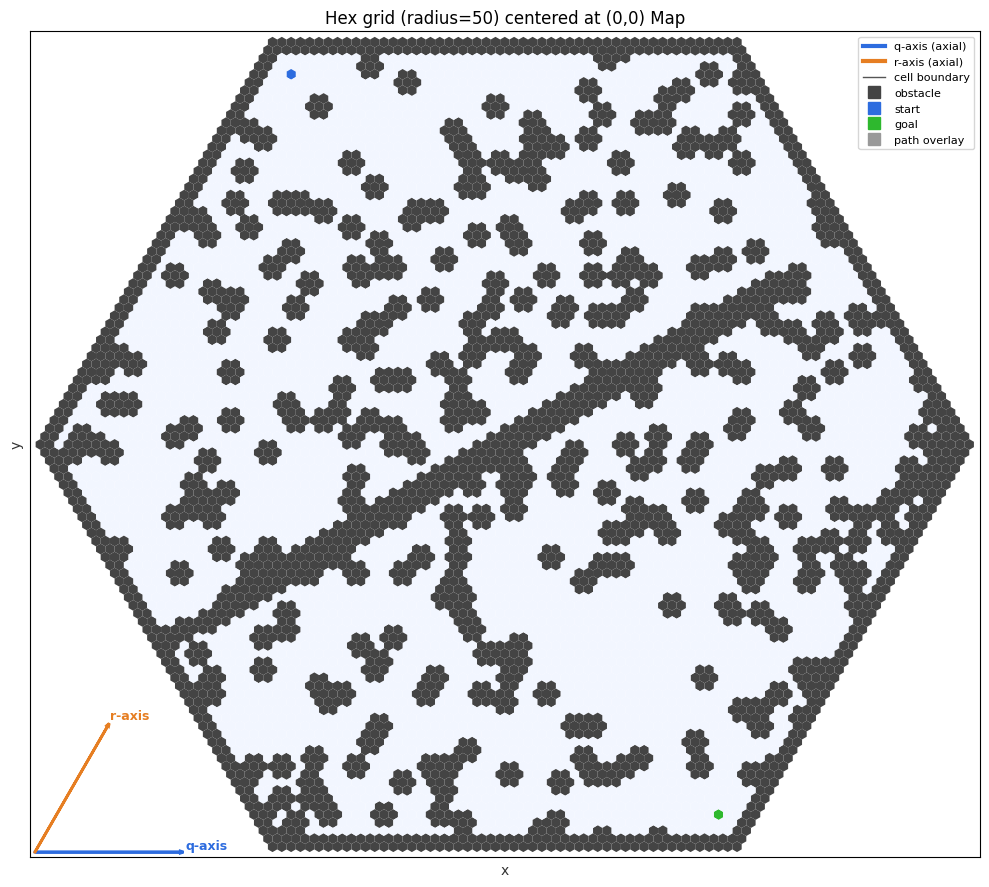

In [6]:
plot_hex_grid_2(
    hg.obstacles.union(problem.collision_radius_map),
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    #path = hexes_in_between_solid(HexCoord(q=0, r=0), HexCoord(q=14, r=10)),
    #path=problem.get_available_hexes_in_dir(start, problem.DIRECTIONS[0], ray_range = 50),
    #path=problem.actions(hs.root),
    #path=set(unique_direction_vectors_up_to_n(HexCoord(0,0), RADIUS)),
    facecolor_path = "#999999",
    #path = set([n.location for n in fsolution[-24:-21]]),
    #path = fsolution,
    linewidth=0,
    plt_title = f"Map",
    save_path=f"map",
)

In [7]:
import time
start_t = time.time()
fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)
search_time = time.time() - start_t
benchmarks = hs.get_benchmarks()
print(f'Search time: {benchmarks["search_time"]}s')
print(f'Solution cost: {benchmarks["solution_cost"]}')

Search time: 12.485055208206177s
Solution cost: 17.67397793915819


<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Solution Forward'}, xlabel='x', ylabel='y'>

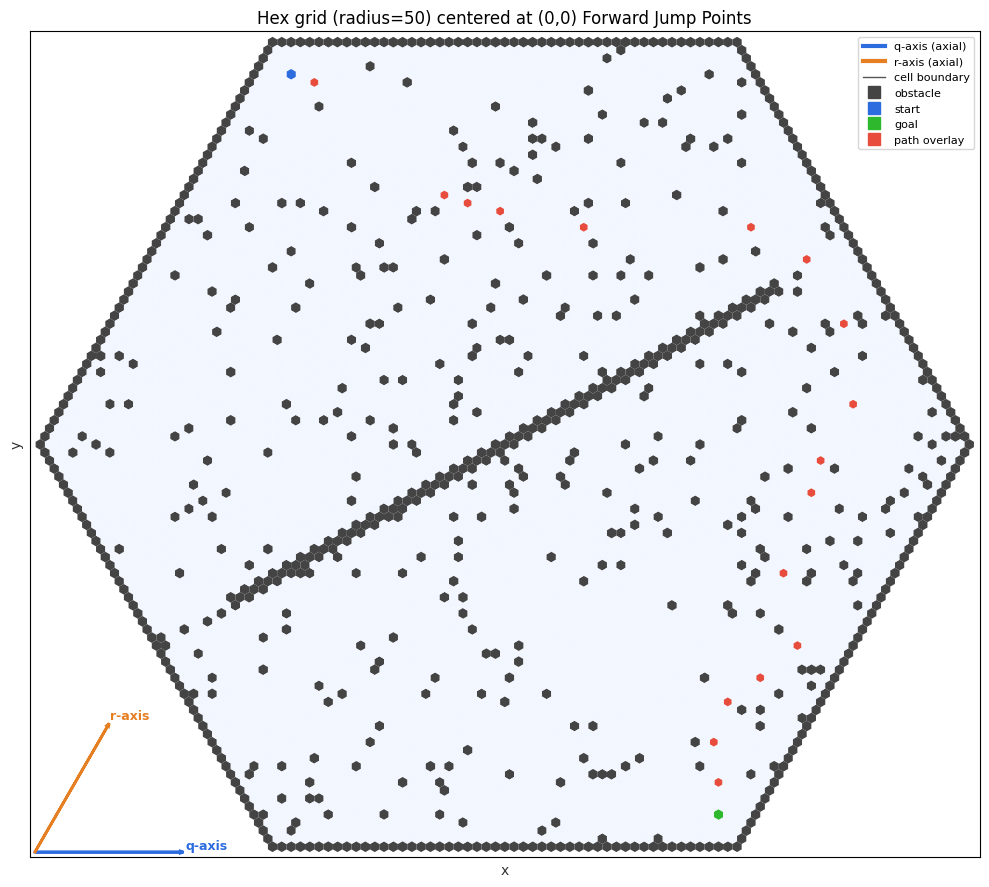

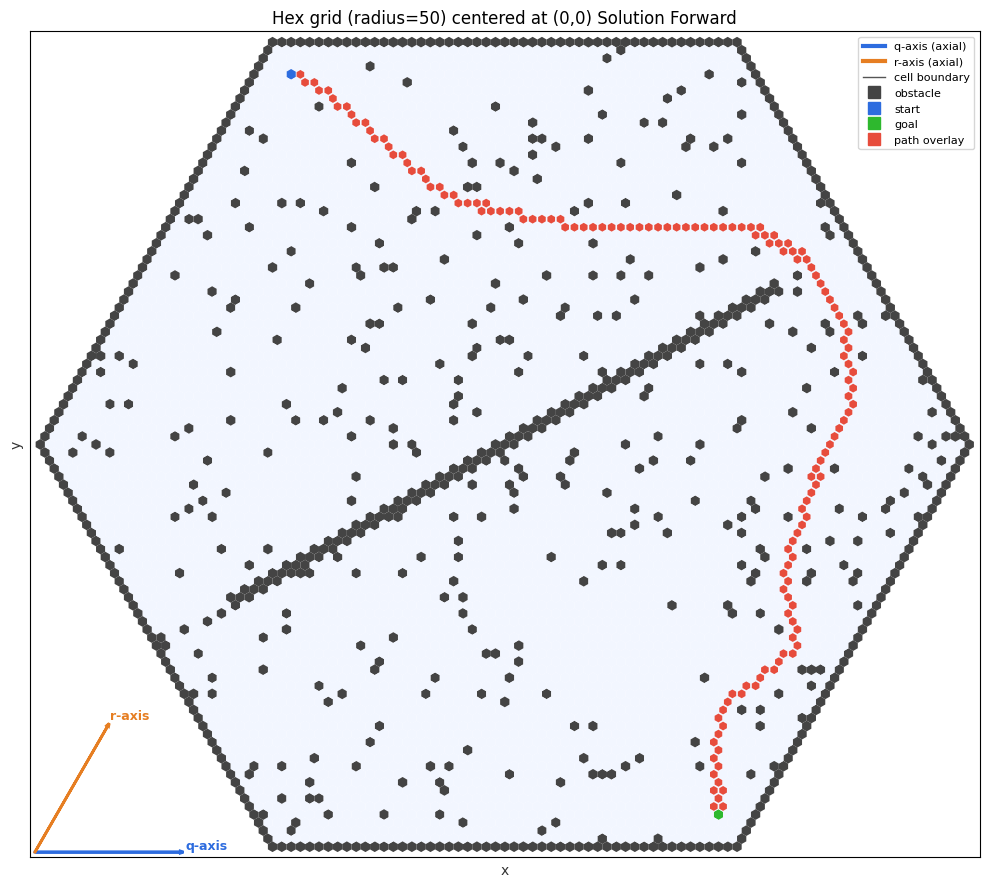

In [8]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in fsolution]),
    linewidth=0,
    plt_title = f"Forward Jump Points",
    save_path=f"jump-points-forward",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = fsolution_path,
    linewidth=0,
    plt_title = f"Solution Forward",
    save_path=f"solution-forward",
)

In [9]:
problem_r = problem.reverse()
problem_r.start_v

VelocityState(magnitude=0, direction=None)

In [10]:
hs_r = HStarSearch(
    problem = problem_r,
    heuristic = h_cost_travel_time
)

In [11]:
import time
start_t = time.time()
rsolution = hs_r.search()
rsolution_path = construct_full_solution(rsolution)
search_time = time.time() - start_t
benchmarks_r = hs_r.get_benchmarks()
print(f'Search time: {benchmarks_r["search_time"]}s')
print(f'Solution cost r: {benchmarks_r["solution_cost"]}')
print(f'Solution cost f: {benchmarks["solution_cost"]}')

Search time: 17.260382175445557s
Solution cost r: 17.73502915067355
Solution cost f: 17.67397793915819


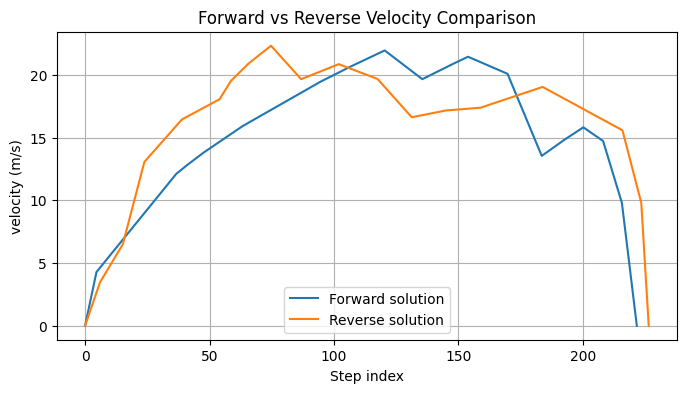

In [12]:
import itertools
f_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in fsolution
))
r_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in rsolution
))

f_vals = [f.velocity.magnitude for f in fsolution]
r_vals = list(reversed([f.velocity.magnitude for f in rsolution]))

plt.figure(figsize=(8, 4))

plt.plot(f_x, f_vals, label="Forward solution")
plt.plot(r_x, r_vals, label="Reverse solution")

plt.xlabel("Step index")
plt.ylabel("velocity (m/s)")
plt.title("Forward vs Reverse Velocity Comparison")

plt.legend()
plt.grid(True)

plt.show()


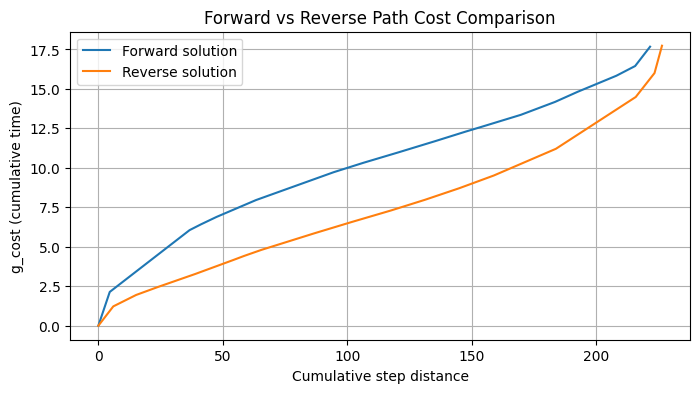

In [13]:
f_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in fsolution
))
r_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in rsolution
))

f_vals = [f.g_cost for f in fsolution]
r_vals = [f.g_cost for f in rsolution]

plt.figure(figsize=(8, 4))

plt.plot(f_x, f_vals, label="Forward solution")
plt.plot(r_x, r_vals, label="Reverse solution")

plt.xlabel("Cumulative step distance")
plt.ylabel("g_cost (cumulative time)")
plt.title("Forward vs Reverse Path Cost Comparison")

plt.legend()
plt.grid(True)

plt.show()

<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Solution Reverse'}, xlabel='x', ylabel='y'>

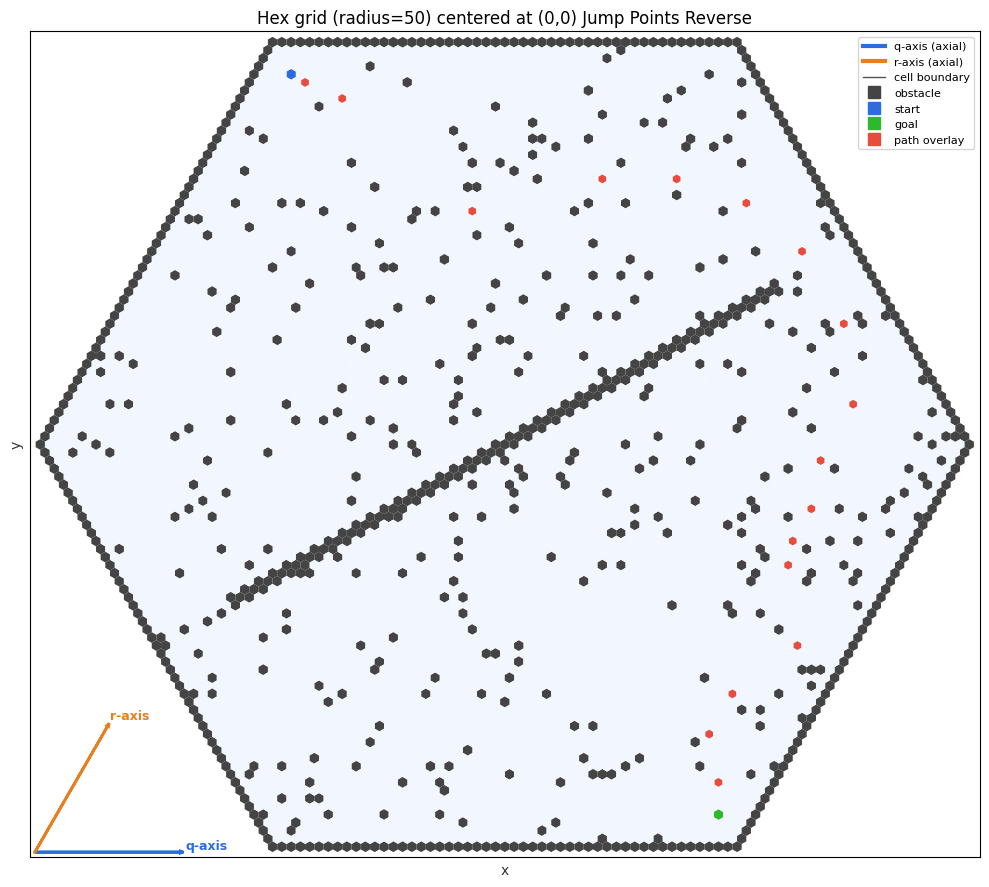

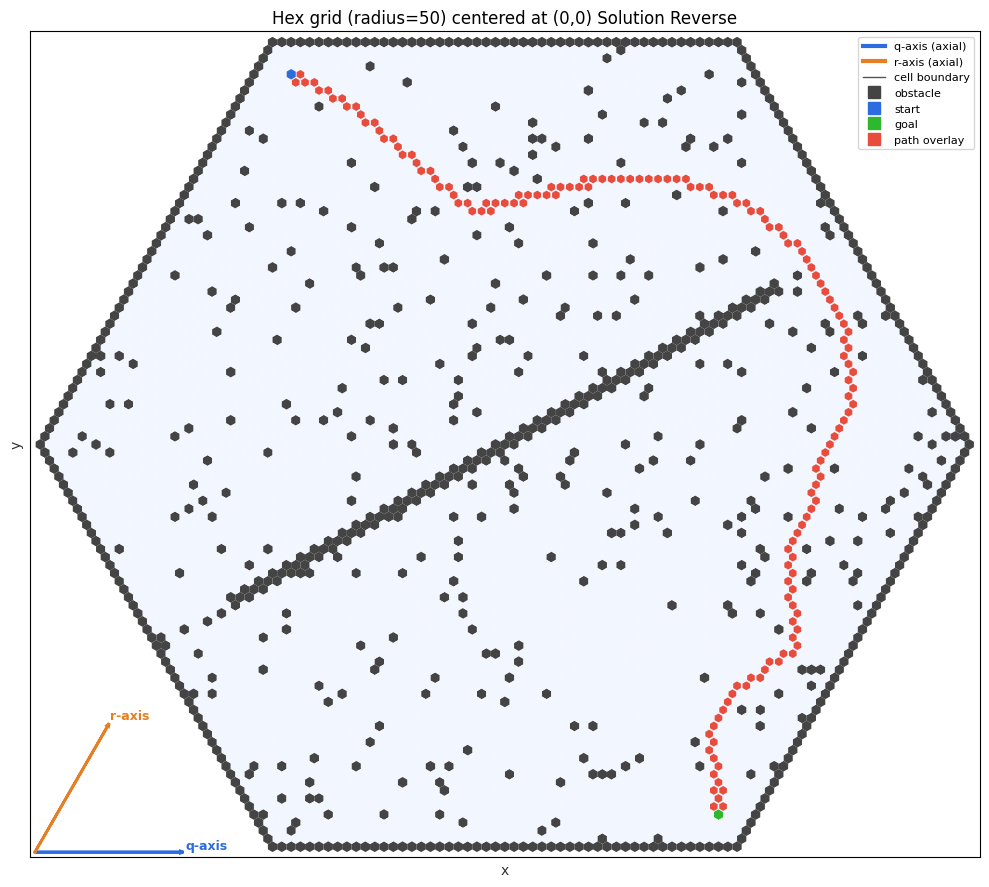

In [14]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in rsolution]),
    linewidth=0,
    plt_title = f"Jump Points Reverse",
    save_path=f"jump-points-reverse",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = rsolution_path,
    linewidth=0,
    plt_title = f"Solution Reverse",
    save_path=f"solution-reverse",
)

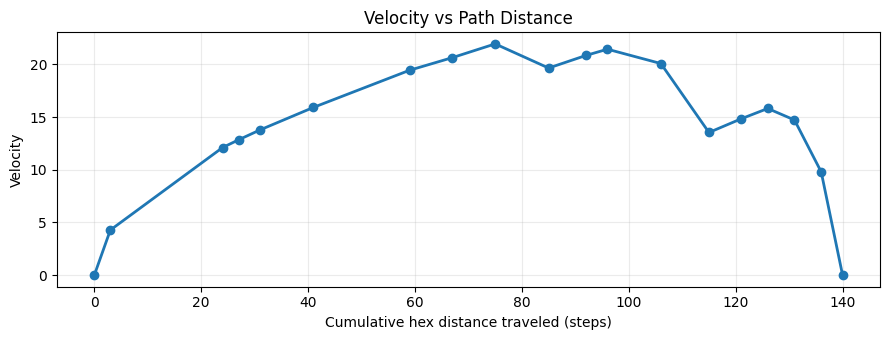

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [15]:
plot_velocity_profile(fsolution)

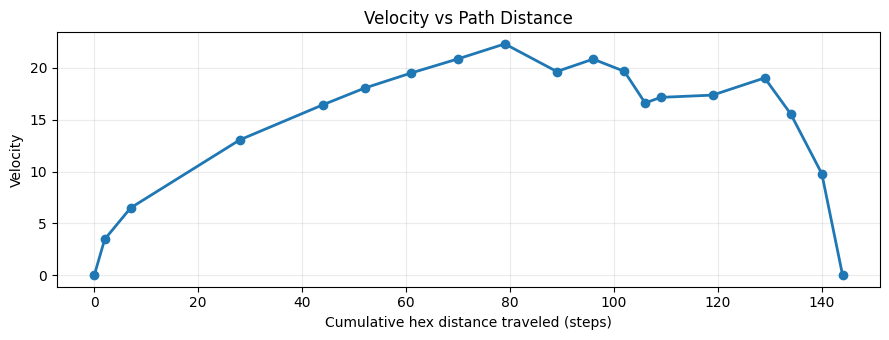

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [16]:
plot_velocity_profile(list(reversed(rsolution)))

In [17]:
problem.generate_collision_radius_map(problem.collision_radius, set(fsolution_path))

{HexCoord(q=-1, r=26),
 HexCoord(q=-1, r=28),
 HexCoord(q=-10, r=27),
 HexCoord(q=-10, r=29),
 HexCoord(q=-11, r=27),
 HexCoord(q=-11, r=29),
 HexCoord(q=-12, r=27),
 HexCoord(q=-12, r=29),
 HexCoord(q=-13, r=28),
 HexCoord(q=-13, r=30),
 HexCoord(q=-14, r=28),
 HexCoord(q=-14, r=30),
 HexCoord(q=-15, r=28),
 HexCoord(q=-15, r=30),
 HexCoord(q=-16, r=28),
 HexCoord(q=-16, r=30),
 HexCoord(q=-17, r=28),
 HexCoord(q=-17, r=31),
 HexCoord(q=-18, r=29),
 HexCoord(q=-18, r=31),
 HexCoord(q=-19, r=29),
 HexCoord(q=-19, r=31),
 HexCoord(q=-2, r=26),
 HexCoord(q=-2, r=28),
 HexCoord(q=-20, r=29),
 HexCoord(q=-20, r=31),
 HexCoord(q=-21, r=30),
 HexCoord(q=-21, r=32),
 HexCoord(q=-22, r=30),
 HexCoord(q=-22, r=32),
 HexCoord(q=-23, r=31),
 HexCoord(q=-23, r=33),
 HexCoord(q=-24, r=31),
 HexCoord(q=-24, r=33),
 HexCoord(q=-25, r=32),
 HexCoord(q=-25, r=34),
 HexCoord(q=-26, r=33),
 HexCoord(q=-26, r=35),
 HexCoord(q=-27, r=33),
 HexCoord(q=-27, r=35),
 HexCoord(q=-28, r=34),
 HexCoord(q=-28, r=3

<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Map-constrained'}, xlabel='x', ylabel='y'>

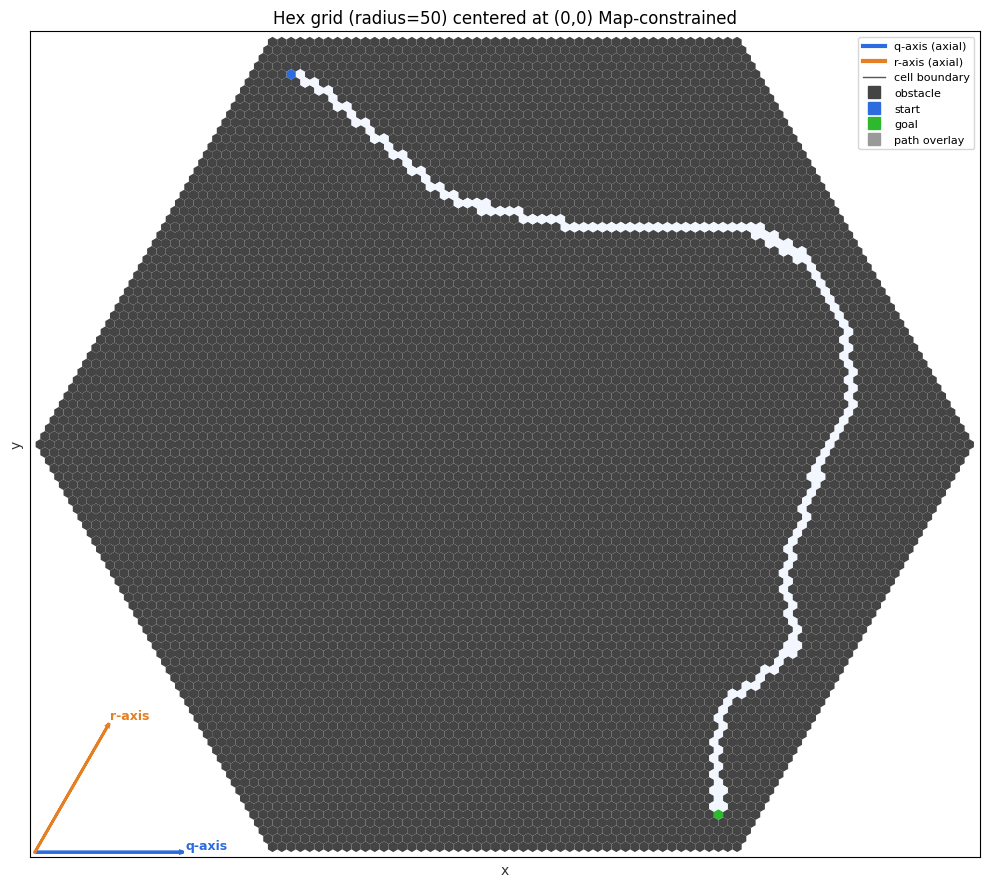

In [18]:
obs_density = 0.05
hex_size = 1
n_obs = int(obs_density * 3 * RADIUS * (RADIUS + 1))
start = HexCoord(q=-RADIUS + 4, r=RADIUS - 4)
#start = HexCoord(0,0)
goal = HexCoord(q=RADIUS - 4, r=-RADIUS + 4)

obs = set(build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = [("fill_all", {})],
    exclude=[start, goal],
    seed=42
).keys())

obs = obs - {start, goal}
obs = obs - problem.generate_collision_radius_map(problem.collision_radius, set(fsolution_path))
obs = obs - set(fsolution_path)

hg = HexGrid(hex_size, obs)

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    start_v = VelocityState(0, None),
    goal_v = VelocityState(0, None)
)
#problem.goal_v=VelocityState(0, problem.DIRECTIONS.index(HexCoord(-1,2))) # approach from the northeast
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

plot_hex_grid_2(
    hg.obstacles.union(problem.collision_radius_map),
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    #path = hexes_in_between_solid(HexCoord(q=0, r=0), HexCoord(q=14, r=10)),
    #path=problem.get_available_hexes_in_dir(start, problem.DIRECTIONS[0], ray_range = 50),
    #path=problem.actions(hs.root),
    #path=set(unique_direction_vectors_up_to_n(HexCoord(0,0), RADIUS)),
    facecolor_path = "#999999",
    #path = set([n.location for n in fsolution[-24:-21]]),
    #path = fsolution,
    linewidth=0,
    plt_title = f"Map-constrained",
    save_path=f"map-constrained",
)

# Draw the outer boundary


In [19]:
import time
start_t = time.time()
fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)
search_time = time.time() - start_t
print(f'Search time: {search_time:.2f}s')
print(f'Solution cost   : {fsolution[-1].f_cost}')


Search time: 0.05s
Solution cost   : 17.67397793915819


<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Solution Forward Constrained'}, xlabel='x', ylabel='y'>

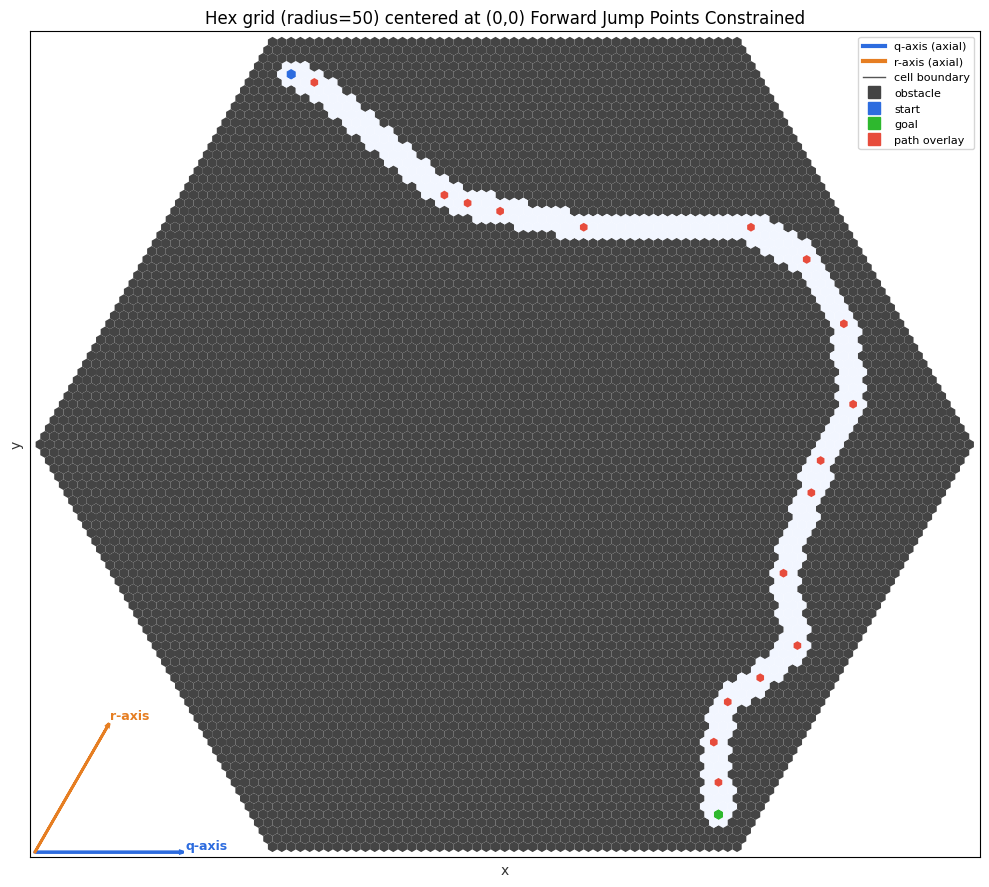

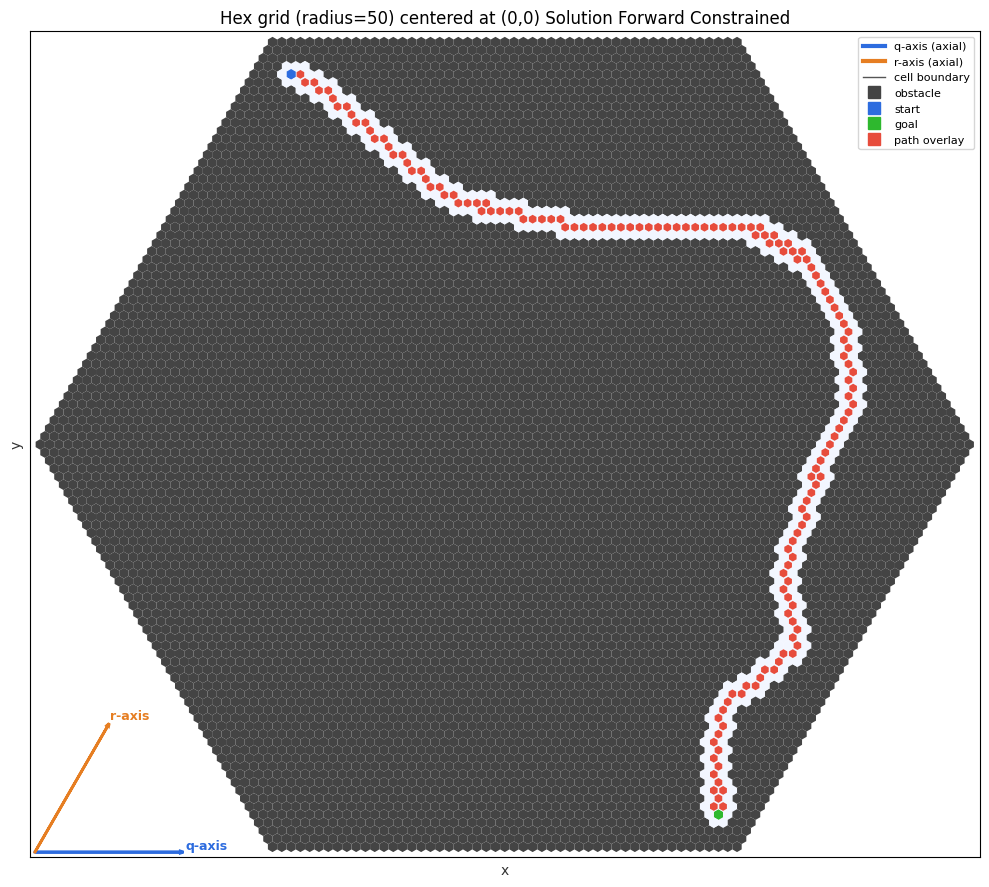

In [20]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in fsolution]),
    linewidth=0,
    plt_title = f"Forward Jump Points Constrained",
    save_path=f"jump-points-forward-c",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = fsolution_path,
    linewidth=0,
    plt_title = f"Solution Forward Constrained",
    save_path=f"solution-forward-c",
)

In [21]:
problem_r = problem.reverse()
problem_r.start_v
hs_r = HStarSearch(
    problem = problem_r,
    heuristic = h_cost_travel_time
)
import time
start_t = time.time()
rsolution = hs_r.search()
rsolution_path = construct_full_solution(rsolution)
search_time = time.time() - start_t
print(f'Search time: {search_time:.2f}s')
print(f'Solution cost   : {rsolution[-1].f_cost}')
print(f'F Solution cost : {fsolution[-1].f_cost}')

Search time: 0.08s
Solution cost   : 17.677361036571384
F Solution cost : 17.67397793915819


<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Solution Reverse'}, xlabel='x', ylabel='y'>

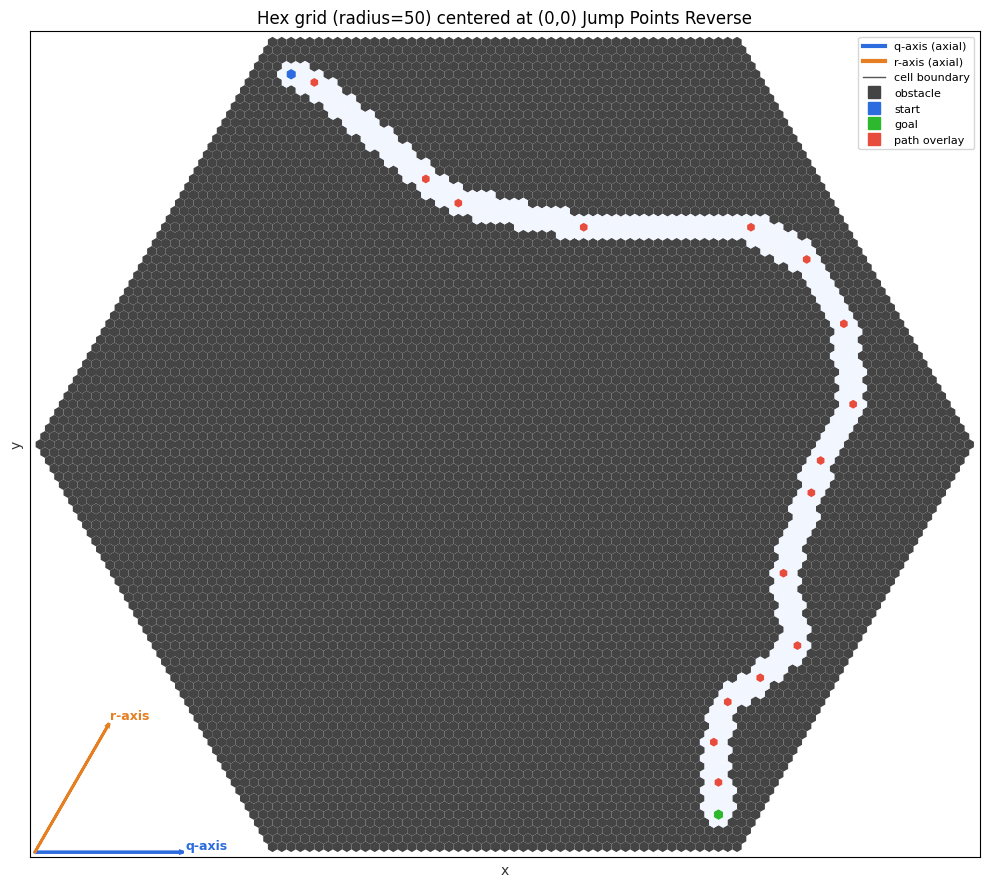

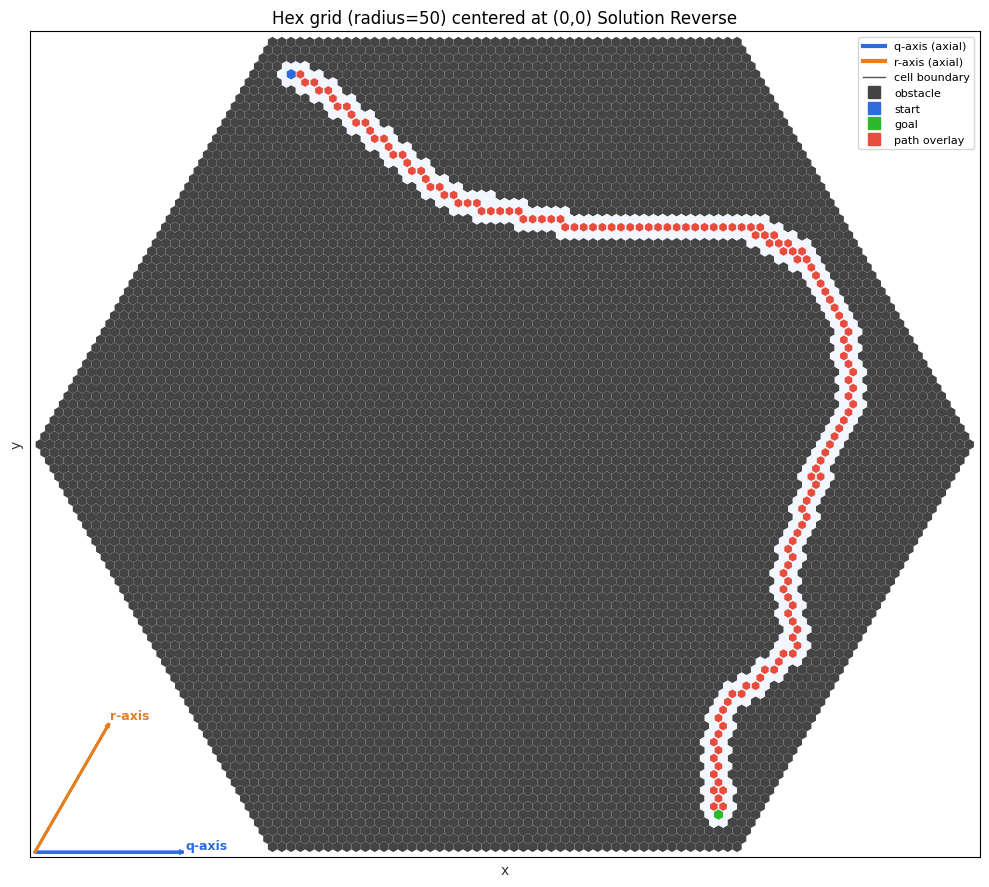

In [22]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in rsolution]),
    linewidth=0,
    plt_title = f"Jump Points Reverse",
    save_path=f"jump-points-reverse",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = rsolution_path,
    linewidth=0,
    plt_title = f"Solution Reverse",
    save_path=f"solution-reverse",
)

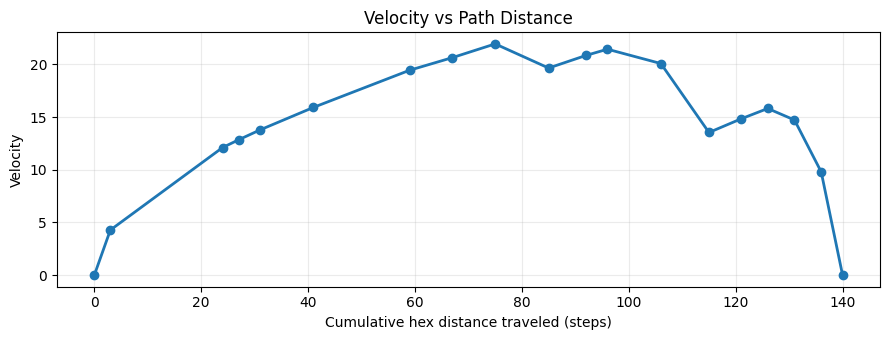

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [23]:
plot_velocity_profile(fsolution)

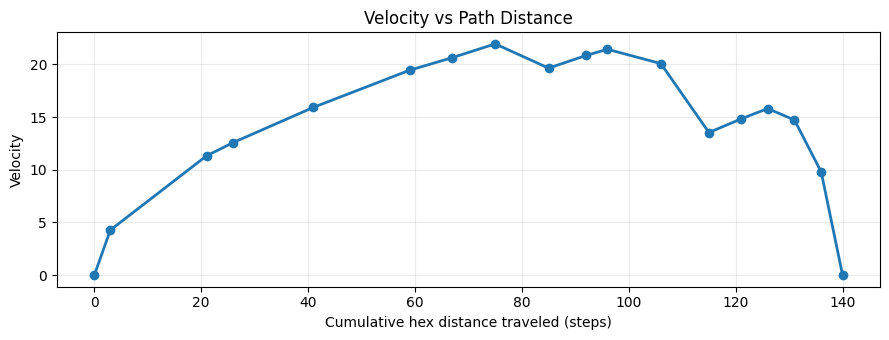

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [24]:
plot_velocity_profile(list(reversed(rsolution)))

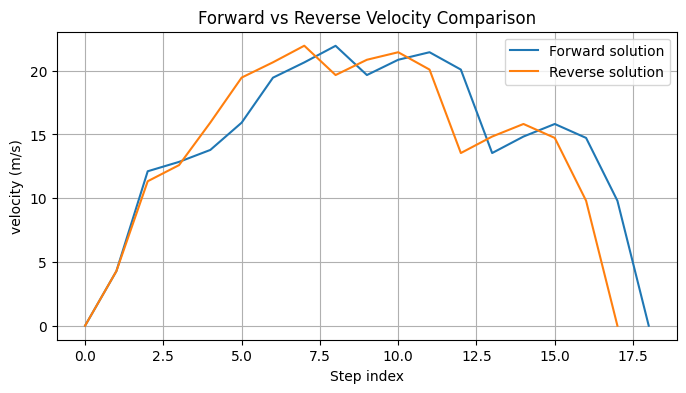

In [25]:

f_vals = [f.velocity.magnitude for f in fsolution]
r_vals = list(reversed([f.velocity.magnitude for f in rsolution]))

plt.figure(figsize=(8, 4))

plt.plot(f_vals, label="Forward solution")
plt.plot(r_vals, label="Reverse solution")

plt.xlabel("Step index")
plt.ylabel("velocity (m/s)")
plt.title("Forward vs Reverse Velocity Comparison")

plt.legend()
plt.grid(True)

plt.show()


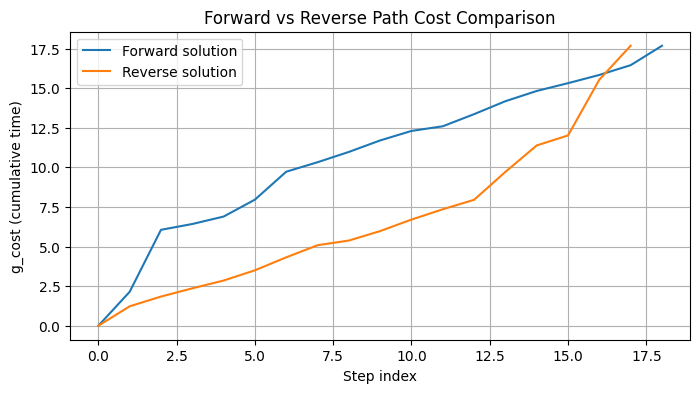

In [26]:

f_vals = [f.g_cost for f in fsolution]
r_vals = [f.g_cost for f in rsolution]

plt.figure(figsize=(8, 4))

plt.plot(f_vals, label="Forward solution")
plt.plot(r_vals, label="Reverse solution")

plt.xlabel("Step index")
plt.ylabel("g_cost (cumulative time)")
plt.title("Forward vs Reverse Path Cost Comparison")

plt.legend()
plt.grid(True)

plt.show()